# Project Fertility PSP — 전체 구현 코드
난임 환자 임신 성공 여부 예측 | 평가지표: ROC-AUC


## 0. 라이브러리 임포트

In [2]:
!pip install catboost lightgbm xgboost scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, log_loss

from catboost import CatBoostClassifier
import lightgbm as lgb
import xgboost as xgb

SEED     = 42
N_FOLDS  = 5
print('라이브러리 임포트 완료')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00
라이브러리 임포트 완료


## 1. 데이터 로딩

In [3]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
sub   = pd.read_csv('sample_submission.csv')

TARGET = '임신 성공 여부'
ID_COL = 'ID'

print(f'Train: {train.shape}  Test: {test.shape}')
train.head(3)

Train: (256351, 69)  Test: (90067, 68)


,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0


## 2. EDA

### 2-1. 타깃 분포

임신 성공 여부
0    190123
1     66228
Name: count, dtype: int64

성공 비율: 25.8%  →  불균형 데이터


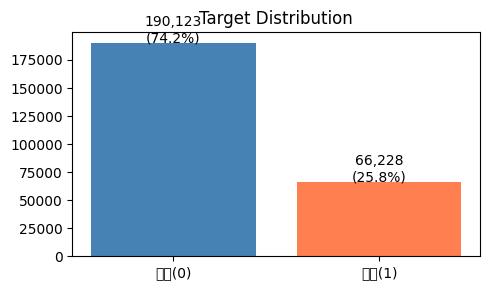

In [4]:
vc = train[TARGET].value_counts()
print(vc)
print(f'\n성공 비율: {vc[1]/len(train)*100:.1f}%  →  불균형 데이터')

fig, ax = plt.subplots(figsize=(5,3))
ax.bar(['실패(0)','성공(1)'], vc.values, color=['steelblue','coral'])
for i,v in enumerate(vc.values):
    ax.text(i, v+300, f'{v:,}\n({v/len(train)*100:.1f}%)', ha='center')
ax.set_title('Target Distribution')
plt.tight_layout(); plt.show()

### 2-2. 결측치 분석

In [5]:
miss = train.isnull().sum()
miss = miss[miss>0].sort_values(ascending=False)
miss_df = pd.DataFrame({'결측 수': miss, '결측률(%)': (miss/len(train)*100).round(2)})
print(miss_df.to_string())

                         결측 수  결측률(%)
난자 해동 경과일              254915   99.44
PGS 시술 여부              254422   99.25
PGD 시술 여부              254172   99.15
착상 전 유전 검사 사용 여부       253633   98.94
임신 시도 또는 마지막 임신 경과 연수  246981   96.34
배아 해동 경과일              215982   84.25
난자 채취 경과일               57488   22.43
난자 혼합 경과일               53735   20.96
배아 이식 경과일               43566   16.99
저장된 배아 수                 6291    2.45
단일 배아 이식 여부              6291    2.45
배아 생성 주요 이유              6291    2.45
착상 전 유전 진단 사용 여부         6291    2.45
총 생성 배아 수                6291    2.45
미세주입된 난자 수               6291    2.45
기증 배아 사용 여부              6291    2.45
해동 난자 수                  6291    2.45
미세주입 후 저장된 배아 수          6291    2.45
해동된 배아 수                 6291    2.45
미세주입 배아 이식 수             6291    2.45
이식된 배아 수                 6291    2.45
미세주입에서 생성된 배아 수          6291    2.45
수집된 신선 난자 수              6291    2.45
파트너 정자와 혼합된 난자 수         6291    2.45
신선 배아 사용 여부              6291    2.45
동결 배아 사용 여부 

### 2-3. 주요 변수별 임신 성공률

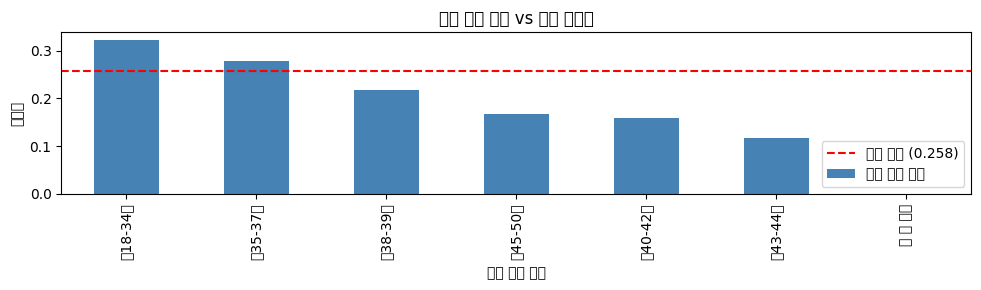

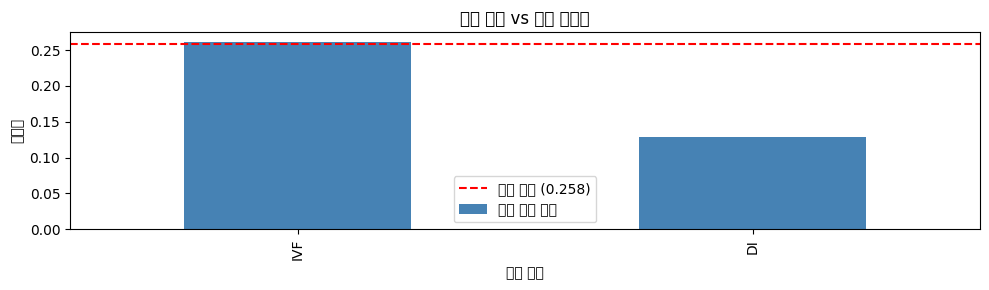

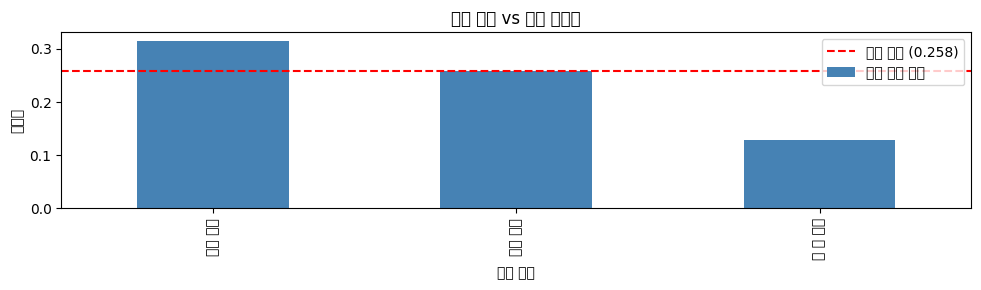

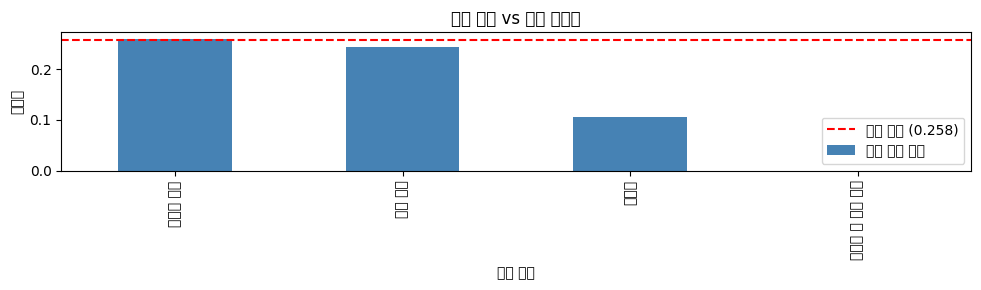

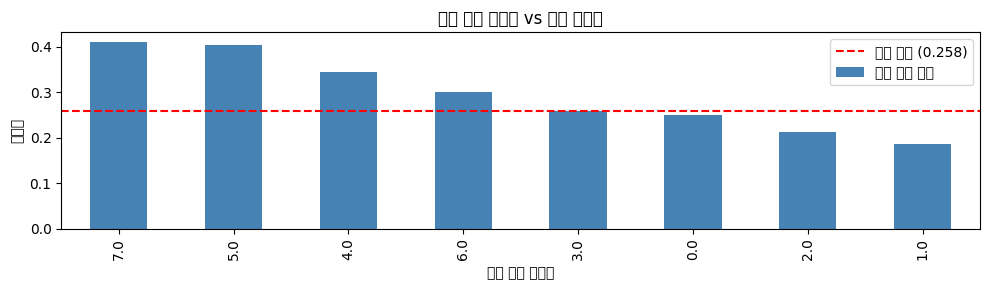

In [6]:
def plot_cat_target(df, col, target=TARGET, figsize=(10,3)):
    if col not in df.columns: return
    tmp = df.groupby(col)[target].mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=figsize)
    tmp.plot(kind='bar', ax=ax, color='steelblue')
    ax.axhline(df[target].mean(), color='red', ls='--', label=f'전체 평균 ({df[target].mean():.3f})')
    ax.set_title(f'{col} vs 임신 성공률'); ax.set_ylabel('성공률'); ax.legend()
    plt.tight_layout(); plt.show()

for col in ['시술 당시 나이','시술 유형','난자 출처','정자 출처','배아 이식 경과일']:
    plot_cat_target(train, col)

### 2-4. 배아 이식 경과일 상세

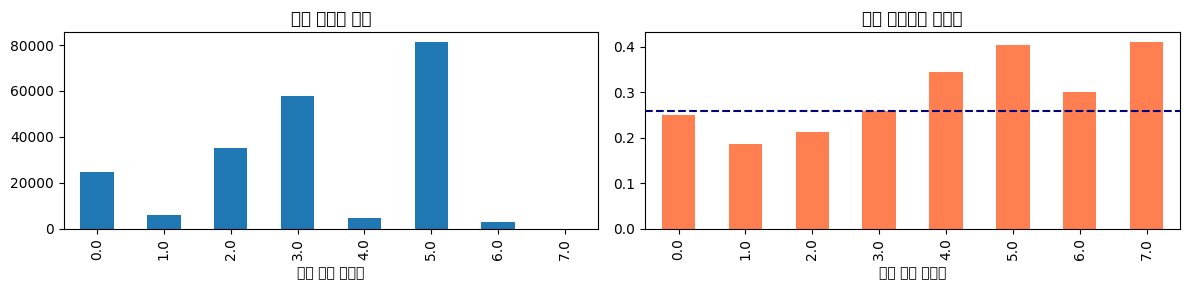

In [7]:
fig, axes = plt.subplots(1,2,figsize=(12,3))
train['배아 이식 경과일'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='이식 경과일 분포')
train.groupby('배아 이식 경과일')[TARGET].mean().plot(kind='bar', ax=axes[1],
    title='이식 경과일별 성공률', color='coral')
axes[1].axhline(train[TARGET].mean(), color='navy', ls='--')
plt.tight_layout(); plt.show()

## 3. 전처리 및 피처 엔지니어링

### 3-1. Train/Test 합치기

In [8]:
train['_is_train'] = 1
test['_is_train']  = 0
test[TARGET] = np.nan
data = pd.concat([train, test], axis=0, ignore_index=True)
print(f'합친 데이터: {data.shape}')

합친 데이터: (346418, 70)


### 3-2. 파생변수 생성

In [9]:
# ── 나이 순서형 ───────────────────────────────────────────────────────────
AGE_ORDER = {'만18-34세':0,'만35-37세':1,'만38-39세':2,
             '만40-42세':3,'만43-44세':4,'만45-50세':5,'알 수 없음':-1}
data['age_ord']   = data['시술 당시 나이'].map(AGE_ORDER)
data['age_ge38']  = (data['age_ord'] >= 2).astype(int)
data['age_ge40']  = (data['age_ord'] >= 3).astype(int)
data['age_ge43']  = (data['age_ord'] >= 4).astype(int)

# ── 시술 횟수 순서형 ─────────────────────────────────────────────────────────
PROC_ORDER = {'0회':0,'1회':1,'2회':2,'3회':3,'4회':4,'5회':5,'6회 이상':6}
for col_raw, col_new in [
    ('총 시술 횟수',        'total_proc_ord'),
    ('클리닉 내 총 시술 횟수','clinic_proc_ord'),
    ('IVF 시술 횟수',       'ivf_proc_ord'),
    ('DI 시술 횟수',        'di_proc_ord'),
    ('총 임신 횟수',        'total_preg_ord'),
    ('총 출산 횟수',        'total_birth_ord'),
]:
    data[col_new] = data[col_raw].map(PROC_ORDER)

# ── 특정 시술 유형 토큰화 ─────────────────────────────────────────────────────
spec = data['특정 시술 유형'].fillna('').str.upper()
data['has_icsi']       = spec.str.contains('ICSI').astype(int)
data['has_ivf_token']  = spec.str.contains('IVF').astype(int)
data['has_blastocyst'] = spec.str.contains('BLAST').astype(int)
data['has_ah']         = spec.str.contains('AH').astype(int)
data['has_frozen_tok'] = spec.str.contains('FER|FET|FROZEN').astype(int)
data['has_iui']        = spec.str.contains('IUI').astype(int)          # ★ 추가
data['spec_has_colon'] = data['특정 시술 유형'].fillna('').str.contains(':').astype(int)  # ★ 추가
data['spec_has_slash'] = data['특정 시술 유형'].fillna('').str.contains('/').astype(int)  # ★ 추가

# ── 배아 이식 경과일 파생 ────────────────────────────────────────────────────
data['transfer_day5']     = (data['배아 이식 경과일'] == 5).astype(int)
data['transfer_day45']    = data['배아 이식 경과일'].isin([4,5]).astype(int)
data['transfer_day_miss'] = data['배아 이식 경과일'].isnull().astype(int)          # ★ 추가
transfer_cnt = data['이식된 배아 수']
transfer_day = data['배아 이식 경과일']
data['transfer_cnt_zero'] = (transfer_cnt.fillna(0) == 0).astype(int)              # ★ 추가
data['no_transfer']       = ((transfer_cnt.fillna(0) == 0) | transfer_day.isnull()).astype(int)  # ★ 추가
data['transfer_day_x_cnt'] = transfer_day.fillna(-1) * transfer_cnt.fillna(0)      # ★ 교호작용

# ── 배아 수치 비율 ───────────────────────────────────────────────────────────
def safe_ratio(a, b):
    b_safe = b.replace(0, float('nan'))
    return (a / b_safe).replace([float('inf'), float('-inf')], float('nan'))

data['transfer_ratio']    = safe_ratio(data['이식된 배아 수'],    data['총 생성 배아 수'])
data['inject_ratio']      = safe_ratio(data['미세주입된 난자 수'], data['혼합된 난자 수'])
data['store_ratio']       = safe_ratio(data['저장된 배아 수'],    data['총 생성 배아 수'])
data['thawed_per_stored'] = safe_ratio(data['해동된 배아 수'],    data['저장된 배아 수'])  # ★ 추가

# ── 배아 관련 결측 ────────────────────────────────────────────────────────────
embryo_num_cols = ['총 생성 배아 수','미세주입된 난자 수','미세주입에서 생성된 배아 수',
                   '이식된 배아 수','저장된 배아 수','혼합된 난자 수']
data['embryo_missing_cnt'] = data[embryo_num_cols].isnull().sum(axis=1)
data['embryo_all_missing'] = data[embryo_num_cols].isnull().all(axis=1).astype(int)  # ★ 추가 (DI 구분 강화)

# ── DI 시술 여부 ─────────────────────────────────────────────────────────────
data['is_di'] = (data['시술 유형'] == 'DI').astype(int)

# ── 난자/정자 기증 여부 ──────────────────────────────────────────────────────
data['egg_donated']   = (data['난자 출처'] == '기증 제공').astype(int)
data['sperm_donated'] = data['정자 출처'].isin(['기증 제공','배우자 및 기증 제공']).astype(int)
data['age_x_egg_donor'] = data['age_ord'].fillna(-1) * data['egg_donated']          # ★ 수치 교호작용

# ── 조합 문자열 변수 ─────────────────────────────────────────────────────────
data['age_egg_combo']      = data['시술 당시 나이'].astype(str) + '_' + data['난자 출처'].astype(str)
data['age_proc_combo']     = data['시술 당시 나이'].astype(str) + '__' + data['특정 시술 유형'].fillna('').astype(str)  # ★ 추가
data['transfer_day_cnt_combo'] = (                                                  # ★ 추가
    transfer_day.fillna(-1).astype(int).astype(str)
    + '__'
    + transfer_cnt.fillna(-1).astype(int).astype(str)
)

# ── 배아 생성 이유 파생 ──────────────────────────────────────────────────────
reason = data['배아 생성 주요 이유'].fillna('')
data['reason_current']      = reason.str.contains('현재 시술용').astype(int)
data['reason_storage_only'] = (                                                     # ★ 추가
    reason.str.contains('배아 저장용') &
    ~reason.str.contains('현재 시술용') &
    ~reason.str.contains('기증용')
).astype(int)
data['reason_donation'] = reason.str.contains('기증용').astype(int)                 # ★ 추가

print(f'파생변수 포함 컬럼 수: {data.shape[1]}')
print(f'신규 추가 파생변수: 14개')


파생변수 포함 컬럼 수: 110
신규 추가 파생변수: 14개


### 3-3. 결측치 처리

In [10]:
cat_cols = data.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != ID_COL]

num_cols = data.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols = [c for c in num_cols if c not in [TARGET, '_is_train']]

# 범주형 → '__MISSING__'
for c in cat_cols:
    data[c] = data[c].fillna('__MISSING__')

# 수치형 → train 중앙값 (leakage 방지)
train_medians = data[data['_is_train']==1][num_cols].median()
for c in num_cols:
    data[c] = data[c].fillna(train_medians[c])

remaining = data.drop(columns=[TARGET]).isnull().sum().sum()
print(f'남은 결측치: {remaining}  (TARGET 제외)')

남은 결측치: 0  (TARGET 제외)


### 3-4. 인코딩 및 데이터 분리

In [11]:
FEATURE_COLS = [c for c in data.columns if c not in [TARGET, ID_COL, '_is_train']]

# ── CatBoost용: 원본 범주형 유지 ─────────────────────────────────────────────
train_cat  = data[data['_is_train']==1].copy()
test_cat   = data[data['_is_train']==0].copy()
X_cat      = train_cat[FEATURE_COLS]
X_test_cat = test_cat[FEATURE_COLS]
y          = train_cat[TARGET].values.astype(int)
cat_feature_names   = [c for c in cat_cols if c in FEATURE_COLS]
cat_feature_indices = [FEATURE_COLS.index(c) for c in cat_feature_names]

# ── LightGBM / XGBoost용: Label Encoding ─────────────────────────────────────
data_le = data.copy()
le_dict = {}
for c in cat_cols:
    le = LabelEncoder()
    data_le[c] = le.fit_transform(data_le[c].astype(str))
    le_dict[c] = le

train_le = data_le[data_le['_is_train']==1]
test_le  = data_le[data_le['_is_train']==0]
X    = train_le[FEATURE_COLS].values
X_te = test_le[FEATURE_COLS].values

print(f'Features: {len(FEATURE_COLS)}')
print(f'CatBoost 범주형 피처 수: {len(cat_feature_indices)}')
print(f'X shape: {X.shape}  |  X_test shape: {X_te.shape}')

Features: 107
CatBoost 범주형 피처 수: 23
X shape: (256351, 107)  |  X_test shape: (90067, 107)


## 4. K-Fold 모델링

In [12]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

def run_kfold(name, get_model_fn, X_tr, y_tr, X_te, use_df=False):
    """
    K-Fold 학습 → OOF 예측 및 Test 예측 반환
    use_df: True이면 DataFrame(CatBoost), False이면 numpy array
    """
    oof       = np.zeros(len(y_tr))
    test_pred = np.zeros(len(X_te) if not use_df else len(X_te))
    idx_iter  = range(len(y_tr)) if use_df else X_tr

    for fold, (tri, vali) in enumerate(skf.split(idx_iter, y_tr)):
        Xtr  = X_tr.iloc[tri]  if use_df else X_tr[tri]
        Xval = X_tr.iloc[vali] if use_df else X_tr[vali]
        ytr, yval = y_tr[tri], y_tr[vali]

        m = get_model_fn()
        if name == 'CatBoost':
            m.fit(Xtr, ytr, eval_set=(Xval, yval), verbose=False)
        elif name == 'LightGBM':
            m.fit(Xtr, ytr, eval_set=[(Xval, yval)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                              lgb.log_evaluation(-1)])
        elif name == 'XGBoost':
            m.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
        else:
            m.fit(Xtr, ytr)

        oof[vali]   = m.predict_proba(Xval)[:, 1]
        test_pred  += m.predict_proba(X_te)[:, 1] / N_FOLDS

        fold_auc = roc_auc_score(yval, oof[vali])
        print(f'  [{name}] Fold {fold+1}/{N_FOLDS}  AUC: {fold_auc:.5f}')

    oof_auc = roc_auc_score(y_tr, oof)
    print(f'  [{name}] OOF AUC: {oof_auc:.5f}\n')
    return oof, test_pred, oof_auc

### 4-1. CatBoost

In [13]:
def get_catboost():
    return CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        cat_features=cat_feature_indices,
        eval_metric='AUC',
        early_stopping_rounds=50,
        random_seed=SEED,
        verbose=False
    )

oof_cat, pred_cat, auc_cat = run_kfold(
    'CatBoost', get_catboost, X_cat, y, X_test_cat, use_df=True
)

  [CatBoost] Fold 1/5  AUC: 0.73825
  [CatBoost] Fold 2/5  AUC: 0.74320
  [CatBoost] Fold 3/5  AUC: 0.74017
  [CatBoost] Fold 4/5  AUC: 0.73783
  [CatBoost] Fold 5/5  AUC: 0.74112
  [CatBoost] OOF AUC: 0.74011



### 4-2. LightGBM

In [14]:
def get_lgbm():
    return lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    )

oof_lgb, pred_lgb, auc_lgb = run_kfold(
    'LightGBM', get_lgbm, X, y, X_te
)

  [LightGBM] Fold 1/5  AUC: 0.73713
  [LightGBM] Fold 2/5  AUC: 0.74216
  [LightGBM] Fold 3/5  AUC: 0.73942
  [LightGBM] Fold 4/5  AUC: 0.73738
  [LightGBM] Fold 5/5  AUC: 0.74030
  [LightGBM] OOF AUC: 0.73927



### 4-3. XGBoost

In [15]:
def get_xgboost():
    return xgb.XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_weight=5,
        eval_metric='auc',
        early_stopping_rounds=50,
        random_state=SEED,
        n_jobs=-1,
        verbosity=0
    )

oof_xgb, pred_xgb, auc_xgb = run_kfold(
    'XGBoost', get_xgboost, X, y, X_te
)

  [XGBoost] Fold 1/5  AUC: 0.73757
  [XGBoost] Fold 2/5  AUC: 0.74270
  [XGBoost] Fold 3/5  AUC: 0.73998
  [XGBoost] Fold 4/5  AUC: 0.73768
  [XGBoost] Fold 5/5  AUC: 0.74108
  [XGBoost] OOF AUC: 0.73980



## 5. 모델 비교 및 앙상블

   Model  OOF_AUC   Weight
CatBoost 0.740111 0.333507
LightGBM 0.739266 0.333126
 XGBoost 0.739801 0.333367
Ensemble 0.740251      NaN


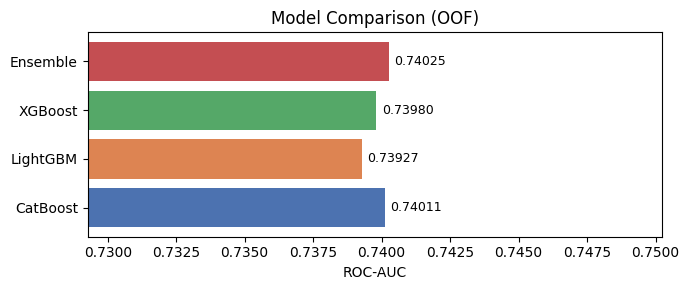

In [16]:
# OOF AUC 비례 가중 평균
aucs = np.array([auc_cat, auc_lgb, auc_xgb])
w    = aucs / aucs.sum()

oof_ens  = oof_cat*w[0] + oof_lgb*w[1] + oof_xgb*w[2]
pred_ens = pred_cat*w[0] + pred_lgb*w[1] + pred_xgb*w[2]
auc_ens  = roc_auc_score(y, oof_ens)

result_df = pd.DataFrame({
    'Model':   ['CatBoost','LightGBM','XGBoost','Ensemble'],
    'OOF_AUC': [auc_cat, auc_lgb, auc_xgb, auc_ens],
    'Weight':  [w[0], w[1], w[2], None]
})
print(result_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7,3))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
ax.barh(result_df['Model'], result_df['OOF_AUC'], color=colors)
ax.set_xlim(result_df['OOF_AUC'].min()-0.01, result_df['OOF_AUC'].max()+0.01)
ax.set_xlabel('ROC-AUC'); ax.set_title('Model Comparison (OOF)')
for i,v in enumerate(result_df['OOF_AUC']):
    ax.text(v+0.0002, i, f'{v:.5f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

## 6. 제출 파일 생성

In [17]:
submission = pd.DataFrame({
    'ID':          test_le[ID_COL].values,
    'probability': pred_ens
})

# 검증
assert len(submission) == len(test),                   '행 수 불일치'
assert submission['probability'].between(0,1).all(),    '확률 범위 오류'
assert submission['probability'].isnull().sum() == 0,   '결측치 존재'

submission.to_csv('submission.csv', index=False)
print('✅ 제출 파일 저장 완료: submission.csv')
submission.head()

✅ 제출 파일 저장 완료: submission.csv


,ID,probability
0,TEST_00000,0.001308
1,TEST_00001,0.002468
2,TEST_00002,0.164758
3,TEST_00003,0.103651
4,TEST_00004,0.518905


## 7. 피처 중요도 분석

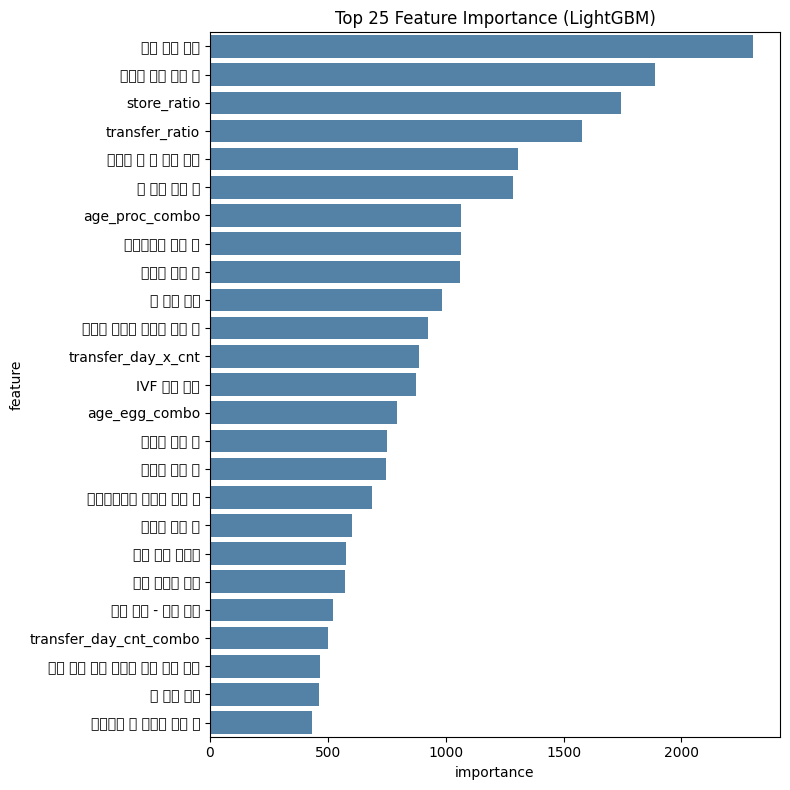

In [18]:
# LightGBM 전체 학습 기준
lgb_full = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_full.fit(X, y)

fi = pd.DataFrame({'feature': FEATURE_COLS, 'importance': lgb_full.feature_importances_})
fi = fi.sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(8,8))
sns.barplot(data=fi, x='importance', y='feature', ax=ax, color='steelblue')
ax.set_title('Top 25 Feature Importance (LightGBM)')
plt.tight_layout(); plt.show()

## 8. 실험 기록

In [19]:
# 매 실험마다 아래 딕셔너리를 업데이트하여 기록
record = {
    'version':      'v1_baseline_ensemble',
    'cat_oof':       round(auc_cat, 5),
    'lgb_oof':       round(auc_lgb, 5),
    'xgb_oof':       round(auc_xgb, 5),
    'ensemble_oof':  round(auc_ens, 5),
    'lb_score':      None,   # 리더보드 제출 후 직접 기입
    'note':          'K-Fold=5, 파생변수: age_ord/age_ge38/has_icsi/has_blastocyst/transfer_day5/transfer_ratio 등'
}
pd.DataFrame([record])

,version,cat_oof,lgb_oof,xgb_oof,ensemble_oof,lb_score,note
0,v1_baseline_ensemble,0.74011,0.73927,0.7398,0.74025,None,"K-Fold=5, 파생변수: age_ord/age_ge38/has_icsi/has_..."
